In [1]:
import warnings
warnings.filterwarnings('ignore')

from herbie import Herbie
from herbie.toolbox import pc, EasyMap
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use("mplstyles/textstyle.mplstyle")
import numpy as np
from modules import helpers, plot_setup, colormaps
import shutil
import gc
import os
os.environ["ECCODES_MESSAGES_QUIET"] = "1"
import xarray as xr
import cartopy.crs as ccrs

import s3fs

In [2]:
H = Herbie("2026-01-02 18:00", model="ecmwf", fxx=24)
ds = H.xarray("prate")

✅ Found ┊ model=ifs ┊ product=oper ┊ 2026-Jan-02 18:00 UTC F24 ┊ GRIB2 @ azure-scda ┊ IDX @ azure-scda


In [3]:
def rate_to_refl(rate):
    first = 1.4*np.log10(rate)
    second = 300*np.power(10, first)
    return 10*np.log10(second)

In [4]:
ds["tprate_mmhr"] = ds.tprate*3600
ds["refd"] = rate_to_refl(ds.tprate_mmhr)

Done with 18:00 UTC 03 Jan 2026! Saving...


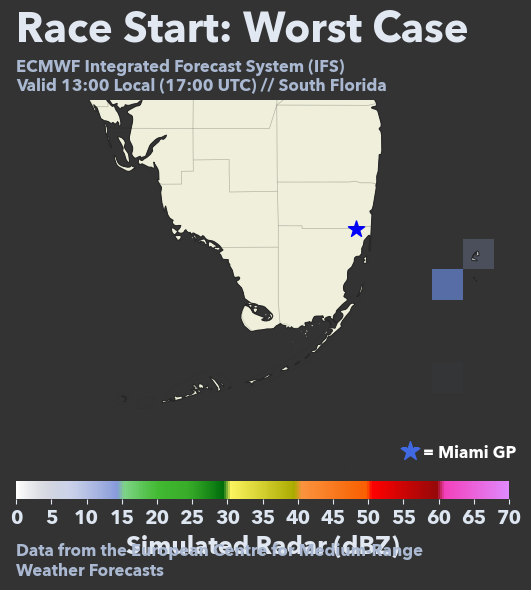

In [ ]:
ax = EasyMap("10m")
ax.COUNTIES(linewidth=0.5)
ax.LAND()
ax.OCEAN(facecolor="#333333")
ax = ax.ax

p = ax.pcolormesh(ds.longitude, ds.latitude, ds.tprate_mmhr, cmap="radar", vmin=0, vmax=50)

ax.set_facecolor("#333333")
ax.set_frame_on(False)

ax.set_ylim(24, 27)
ax.set_xlim(-83, -79)

ax.scatter(-80.24, 25.95, s=150, color="blue", marker="*", alpha=1)
ax.scatter(-79.8, 24.15, s=200, color="royalblue", marker="*", alpha=1)

ax.text(-79.7, 24.13, "= Miami GP", color="white", fontsize=12, va="center")

fig = ax.figure

fig, cax = plot_setup.colorbar(fig, ax, p, "Simulated Radar (dBZ)", np.arange(0, 50, 5))

plotargs = [
    "Race Start: Worst Case",
    "ECMWF Integrated Forecast System (IFS)",
    ds,
    "1km AGL Reflectivity",
    "South Florida",
    "the European Centre for Medium-Range\nWeather Forecasts"
]

plot_setup.finish_plot(fig, ax, plotargs, "images")